<a href="https://colab.research.google.com/github/GDVevo/ml_uni/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%967_Random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №7. Random forest**

## **Задание 1. Обучите классификатор Random Forest для решения задачи бинарной классификации: для каждого человека научиться предсказывать, выживет ли он при крушении Титаника.**



Ссылка на датасет: https://www.kaggle.com/c/titanic/data

### 1. Устанавливаем зависимости

In [26]:
# Ваш код
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Импортируем датасет

In [27]:
# Ваш код
!wget 'https://drive.google.com/uc?export=download&id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB' -O test.csv
!wget 'https://drive.google.com/uc?export=download&id=1oDzBtqrXFDnc4ABbAi5hy9UXXT5uVdbD' -O train.csv

--2026-04-10 10:36:24--  https://drive.google.com/uc?export=download&id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB
Resolving drive.google.com (drive.google.com)... 173.194.216.101, 173.194.216.138, 173.194.216.102, ...
Connecting to drive.google.com (drive.google.com)|173.194.216.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB&export=download [following]
--2026-04-10 10:36:24--  https://drive.usercontent.google.com/download?id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 108.177.11.132, 2607:f8b0:400c:c01::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|108.177.11.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28629 (28K) [application/octet-stream]
Saving to: ‘test.csv’

test.csv            100%[===================>]  27.96K  --.-KB/s    i

In [23]:
df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3. Производим разведовательный анализ данных


Получим представление о данных в датасете:

In [15]:
# Ваш код
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [16]:
test_df.info()
test_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


### 4. Сформируем обучающую и тестовую выборки:


In [24]:
# Ваш код
# поделим train.csv, игнорим test.csv ибо он предназначен чисто для того датасета из конкурса (не имеет ответов, из-за чего невозможно оценить работу)
from sklearn.model_selection import train_test_split

df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Cabin'], drop_first=True)
df['Age'].fillna(df['Age'].mean())

X_train, X_test, y_train, y_test = train_test_split(df, df['Survived'], test_size = 0.33, random_state = 42)
X_train.shape, X_test.shape

((596, 158), (295, 158))

### 5. Feature Engineering

Поработаем с признаками, выделим важные, изменим форму их представления (при надобности)

In [25]:
# Ваш код
# Удалим колонки с именем/номером билета, т.к. эти данные наименее полезны
X_train2 = X_train.drop(["Name", "Ticket", "PassengerId"], axis=1)
X_test2 = X_test.drop(["Name", "Ticket", "PassengerId"], axis=1)

# для удобства, работа с признаками была проведена в предыдущем пункте

print(X_train2.shape)
display(X_train2.info()) #проверка, нет ли пустых объектов
X_train2.head()

(596, 155)
<class 'pandas.core.frame.DataFrame'>
Index: 596 entries, 6 to 102
Columns: 155 entries, Survived to Cabin_T
dtypes: bool(149), float64(2), int64(4)
memory usage: 119.3 KB


None

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Cabin_A14,...,Cabin_E8,Cabin_F E69,Cabin_F G63,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T
6,0,1,54.0,0,0,51.8625,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
718,0,3,NaN,0,0,15.5000,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
685,0,2,25.0,1,2,41.5792,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
73,0,3,26.0,1,0,14.4542,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
882,0,3,22.0,0,0,10.5167,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


### 6. Построение базовой модели:

In [19]:
# Ваш код
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(X_train2, y_train)
y_pred = model.predict(X_test2)

### 7. Оценка точности модели:

#### 7.1. Напишите функцию, принимающую на вход аргументы y_pred, y_test и выполняющую визуализацию матрицы ошибок и отчета классификации

In [8]:
# Ваш код
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report


def vis_cr_me(y_pred, y_test):
  cm = confusion_matrix(y_test, y_pred)
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt=".0f", cmap='Blues')
  plt.title('Матрица ошибок')
  plt.xlabel('Предсказанные')
  plt.ylabel('Реальные')
  plt.show()
  print(classification_report(y_test, y_pred))

#### 7.2. Оцените точность модели:

(295,) (295,)


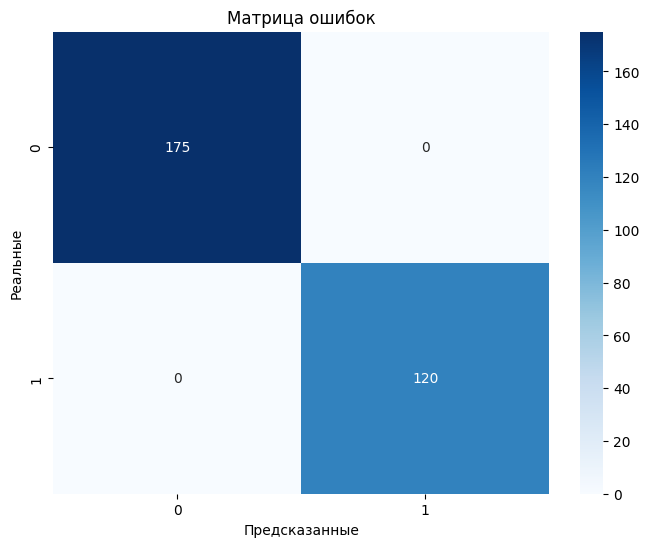

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       175
           1       1.00      1.00      1.00       120

    accuracy                           1.00       295
   macro avg       1.00      1.00      1.00       295
weighted avg       1.00      1.00      1.00       295



In [20]:
# Ваш код
print(y_pred.shape, y_test.shape)
vis_cr_me(y_pred, y_test)

### 8. Тюнинг гиперпараметров модели:

#### RandomSearchCV

In [ ]:
# Ваш код
from sklearn.model_selection import RandomizedSearchCV


param_grid = {
    'n_estimators': [int(x) for x in np.linspace(start=100, stop=500, num=10)],
    'max_leaf_nodes': [int(i) for i in np.linspace(start=2, stop=100, num=10)]
    # при тюнинге было определено, что наилучший результат при max_depth = None, поэтому убираю его для ускорения работы (с 13 мин. понижение до ~4)
}
rf_rcv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=100,
    scoring='accuracy',
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

rf_rcv.fit(X_train2, y_train)

rcv_best_params = rf_rcv.best_params_
print(f"Лучшие параметры: {rcv_best_params}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 100 is smaller than n_iter=300. Running 100 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Лучшие параметры: {'n_estimators': 100, 'max_leaf_nodes': 34}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
50 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

#### GridSearchCV

In [ ]:
# Ваш код
from sklearn.model_selection import GridSearchCV

if rcv_best_params['n_estimators'] >= 6:
  n_estimators = [int(x) for x in range(rcv_best_params['n_estimators']-5, rcv_best_params['n_estimators']+6)]
else:
  n_estimators = [int(x) for x in range(1, 10)]
if rcv_best_params['max_leaf_nodes'] >= 7:
  max_leaf_nodes = [int(i) for i in range(rcv_best_params['max_leaf_nodes']-5, rcv_best_params['max_leaf_nodes']+6)]
else:
  max_leaf_nodes = [int(i) for i in range(2, 11)]

random_grid = {
    'n_estimators': n_estimators,
    'max_leaf_nodes': max_leaf_nodes,
}

rf_cv = GridSearchCV(
    estimator=model,        # модель для настройки
    param_grid=param_grid,  # словарь с параметрами для перебора
    scoring="accuracy",      # метрика для оценки качества моделей
    cv=5,                    # количество фолдов для кросс-валидации
    verbose=0,               # уровень детализации вывода
    n_jobs=-1                # использование всех доступных ядер процессора
)

rf_cv.fit(X_train2, y_train)

best_params = rf_cv.best_params_
best_model = rf_cv.best_estimator_
print(f"Лучшие параметры: {best_params}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
50 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

Лучшие параметры: {'max_leaf_nodes': 34, 'n_estimators': 366}


### 9. Комплексная оценка точности лучшей модели:

[5.94722026e-01 4.45936956e-02 4.53898072e-02 1.70647725e-02
 1.76041641e-02 6.07241140e-02 1.44002634e-01 4.50100036e-03
 1.35477693e-02 1.83566966e-04 3.06654156e-04 5.02914103e-05
 0.00000000e+00 8.63406215e-04 2.09552325e-04 1.04943724e-03
 0.00000000e+00 1.01321650e-04 0.00000000e+00 1.29997982e-04
 0.00000000e+00 0.00000000e+00 0.00000000e+00 6.98913991e-04
 4.89913631e-05 4.85679097e-04 1.02123482e-04 9.62713387e-04
 2.83120232e-04 2.38441817e-04 2.03533229e-04 0.00000000e+00
 6.94561777e-04 2.93075206e-04 0.00000000e+00 0.00000000e+00
 4.13152493e-04 7.05170773e-04 3.22365408e-04 7.90772721e-04
 6.31578620e-04 7.71891371e-04 5.14097272e-04 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.56861182e-04 2.21806310e-04
 9.96911416e-04 0.00000000e+00 2.51753021e-04 3.60639499e-04
 4.05809392e-04 0.00000000e+00 2.43690028e-05 1.13020797e-03
 3.24019393e-04 3.45087862e-04 0.00000000e+00 0.00000000e+00
 0.00000000e+00 4.97547331e-04 3.58224728e-04 3.95979881e-04
 5.97121279e-05 7.439019

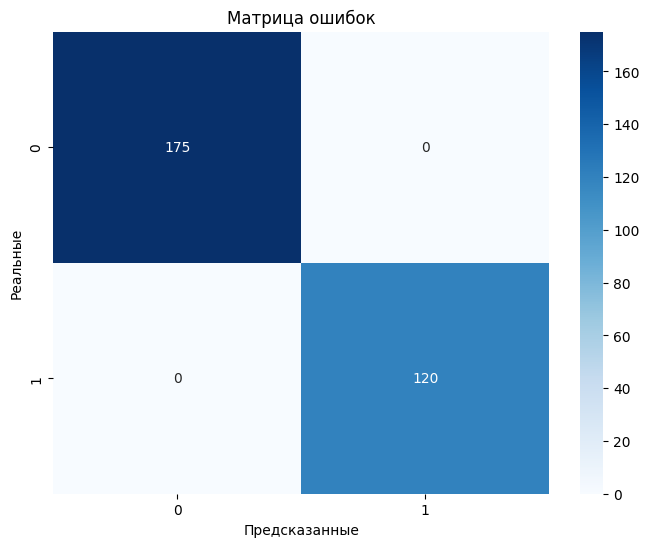

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       175
           1       1.00      1.00      1.00       120

    accuracy                           1.00       295
   macro avg       1.00      1.00      1.00       295
weighted avg       1.00      1.00      1.00       295



In [10]:
# Ваш код
best_model = RandomForestClassifier(max_leaf_nodes=34, n_estimators=366, random_state=1) # чтобы не перезапускать каждый раз перебор, создаем модель по лучшим параметрам
best_model.fit(X_train2, y_train)
y_pred = best_model.predict(X_test2)
print(best_model.feature_importances_)
vis_cr_me(y_pred, y_test)

## **Задание 1 (Данные Титаника из sns)**



Ссылка на датасет: https://www.kaggle.com/c/titanic/data

### 1. Устанавливаем зависимости

In [41]:
# Ваш код
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Импортируем датасет

In [42]:
# Ваш код
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### 3. Производим разведовательный анализ данных


Получим представление о данных в датасете:

In [43]:
# Ваш код
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 4. Сформируем обучающую и тестовую выборки:


In [44]:
# Сначала проведем Feature Engineering, а лишь потом разделим на ввыборки
# Оставляем самые нужные признаки
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]

df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

# Преобразование 'embarked' с использованием one-hot encoding
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)

/tmp/ipykernel_1931/3049122552.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_1931/3049122552.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df, df['survived'], test_size = 0.5, random_state = 42)
X_train.shape, X_test.shape

((445, 9), (446, 9))

### 5. Feature Engineering

Поработаем с признаками, выделим важные, изменим форму их представления (при надобности)

In [46]:
# Ваш код
# проведена ранее

### 6. Построение базовой модели:

In [51]:
# Ваш код
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

### 7. Оценка точности модели:

#### 7.1. Напишите функцию, принимающую на вход аргументы y_pred, y_test и выполняющую визуализацию матрицы ошибок и отчета классификации

In [52]:
# Ваш код
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report


def vis_cr_me(y_pred, y_test):
  cm = confusion_matrix(y_test, y_pred)
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt=".0f", cmap='Blues')
  plt.title('Матрица ошибок')
  plt.xlabel('Предсказанные')
  plt.ylabel('Реальные')
  plt.show()
  print(classification_report(y_test, y_pred))

#### 7.2. Оцените точность модели:

(446,) (446,)


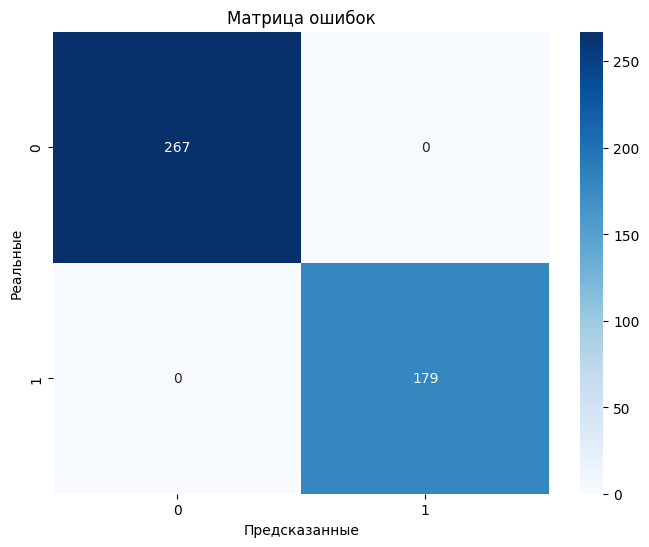

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       267
           1       1.00      1.00      1.00       179

    accuracy                           1.00       446
   macro avg       1.00      1.00      1.00       446
weighted avg       1.00      1.00      1.00       446



In [53]:
# Ваш код
print(y_pred.shape, y_test.shape)
vis_cr_me(y_pred, y_test)

### 8. Тюнинг гиперпараметров модели:

#### RandomSearchCV

In [55]:
# Ваш код
from sklearn.model_selection import RandomizedSearchCV


param_grid = {
    'n_estimators': [int(x) for x in np.linspace(start=100, stop=500, num=10)],
    'max_leaf_nodes': [int(i) for i in np.linspace(start=2, stop=100, num=10)]
    # при тюнинге было определено, что наилучший результат при max_depth = None, поэтому убираю его для ускорения работы (с 13 мин. понижение до ~4)
}
rf_rcv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=100,
    scoring='accuracy',
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

rf_rcv.fit(X_train, y_train)

rcv_best_params = rf_rcv.best_params_
print(f"Лучшие параметры: {rcv_best_params}")

Лучшие параметры: {'n_estimators': 100, 'max_leaf_nodes': 12}


#### GridSearchCV

In [57]:
# Ваш код
from sklearn.model_selection import GridSearchCV

# время выполнения - 3 минуты
if rcv_best_params['n_estimators'] >= 4:
  n_estimators = [int(x) for x in range(rcv_best_params['n_estimators']-3, rcv_best_params['n_estimators']+4)]
else:
  n_estimators = [int(x) for x in range(1, 10)]
if rcv_best_params['max_leaf_nodes'] >= 5:
  max_leaf_nodes = [int(i) for i in range(rcv_best_params['max_leaf_nodes']-3, rcv_best_params['max_leaf_nodes']+4)]
else:
  max_leaf_nodes = [int(i) for i in range(2, 11)]

random_grid = {
    'n_estimators': n_estimators,
    'max_leaf_nodes': max_leaf_nodes,
}

rf_cv = GridSearchCV(
    estimator=model,        # модель для настройки
    param_grid=param_grid,  # словарь с параметрами для перебора
    scoring="accuracy",      # метрика для оценки качества моделей
    cv=5,                    # количество фолдов для кросс-валидации
    verbose=0,               # уровень детализации вывода
    n_jobs=-1                # использование всех доступных ядер процессора
)

rf_cv.fit(X_train, y_train)

best_params = rf_cv.best_params_
best_model = rf_cv.best_estimator_
print(f"Лучшие параметры: {best_params}")

Лучшие параметры: {'max_leaf_nodes': 12, 'n_estimators': 100}


### 9. Комплексная оценка точности лучшей модели:

[0.73793245 0.03781961 0.13915139 0.02555299 0.00782854 0.0043097
 0.0358771  0.00361846 0.00790977]


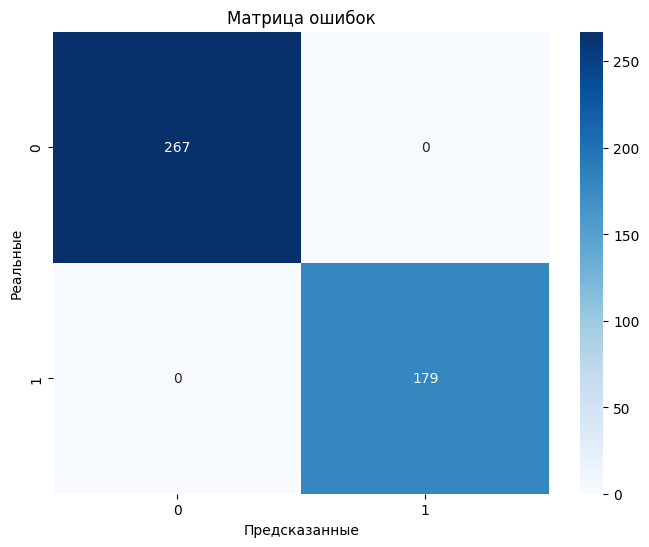

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       267
           1       1.00      1.00      1.00       179

    accuracy                           1.00       446
   macro avg       1.00      1.00      1.00       446
weighted avg       1.00      1.00      1.00       446



In [58]:
# Ваш код
best_model = RandomForestClassifier(max_leaf_nodes=12, n_estimators=100, random_state=1) # чтобы не перезапускать каждый раз перебор, создаем модель по лучшим параметрам
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
print(best_model.feature_importances_)
vis_cr_me(y_pred, y_test)

## **Задание 2. Решите задачу из предыдущего пункта используя другие, ранее пройденные классификаторы. Сравните их точность предсказания с Random Forest**

In [59]:
# Ваш код
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


models = {'lr': LogisticRegression(random_state=1), # проверить работу!!
          'knn': KNeighborsClassifier(),
          'dt': DecisionTreeClassifier(random_state=1)}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")


lr:
  Accuracy:  1.0000

knn:
  Accuracy:  0.7197

dt:
  Accuracy:  1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## **Задание 2.1. Реализуйте функцию, для взаимодействия с обученной Вами моделью**



* Функция должна принимать на вход обученную модель классификатора;

* После вызова функции, у пользователя через консоль запрашиваются значения признаков. При запросе значений нужно вывести пояснения о типе и диапазоне возможных значений. Также реализуйте обработку исключений;

* После ввода значений для всех признаков в консоль, выводится результат работы классификатора.

In [ ]:
# Ваш код
def predictor(model): # модель с уже выполненным fit! доделать!!!!
  res = pd.DataFrame()
  print("Введите следующие признаки:")
  res['Pclass'] = int(input("Класс пассажира: "))
  res['Age'] = int(input("Возраст: "))
  res['Sex'] = int(input("Пол: "))
  res['Embarked'] = int(input("Из какого города отправились: "))
  res['SibSp'] = int(input("Количество родных партнеров/братьев/сестер на борту: "))
  res['Parch'] = int(input("Кол-во родных родителей/детей на борту: "))
  res['Fare'] = int(input("Плата за проезд: "))
  res['Cabin'] = int(input("Номер каюты: "))
  display(res)

  pred = model.predict(res)
  print(pred)

## **Задание 3. Решите задачу регрессии, используя [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html).**

**ОБЯЗАТЕЛЬНО ОСУЩЕСТВИТЕ ПОДБОР ОПТИМАЛЬНЫХ ПАРАМЕТРОВ, ИСПОЛЬЗУЯ RandomSearchCV и GridSearchCV**



* Для выполнения данного задания можете использовать **любой датасет**



Ссылка на один из сайтов-источников датасетов: https://www.kaggle.com/datasets?tags=14203-Regression

In [60]:
# Ваш код
import kagglehub
import pandas as pd

kagglehub.dataset_download("jayaantanaath/student-habits-vs-academic-performance")
df = pd.read_csv('/kaggle/input/student-habits-vs-academic-performance/student_habits_performance.csv') # если вывел ошибку, запустить еще раз

Using Colab cache for faster access to the 'student-habits-vs-academic-performance' dataset.


In [61]:
display(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

None

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [62]:
print(df['diet_quality'].unique()) # выводим "степени важности" признаков для OrdinalEncoder
print(df['internet_quality'].unique())

['Fair' 'Good' 'Poor']
['Average' 'Poor' 'Good']


In [32]:
!pip install category_encoders
import category_encoders as ce

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.3 MB/s eta 0:00:00


In [63]:
from sklearn.model_selection import train_test_split

df2 = df.drop('student_id', axis=1)
df2 = pd.get_dummies(df2, columns=['gender', 'part_time_job', 'extracurricular_participation', 'parental_education_level'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(df2.drop('exam_score', axis=1), df2['exam_score'], test_size = 0.33, random_state = 42)
encoder = ce.OrdinalEncoder(cols=['diet_quality', 'internet_quality'])

X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)

print(X_train.shape)
display(X_train.info()) #проверка, нет ли пустых объектов
X_train.head()

(670, 16)
<class 'pandas.core.frame.DataFrame'>
Index: 670 entries, 703 to 102
Data columns (total 16 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   670 non-null    int64  
 1   study_hours_per_day                   670 non-null    float64
 2   social_media_hours                    670 non-null    float64
 3   netflix_hours                         670 non-null    float64
 4   attendance_percentage                 670 non-null    float64
 5   sleep_hours                           670 non-null    float64
 6   diet_quality                          670 non-null    int64  
 7   exercise_frequency                    670 non-null    int64  
 8   internet_quality                      670 non-null    int64  
 9   mental_health_rating                  670 non-null    int64  
 10  gender_Male                           670 non-null    bool   
 11  gender_Other

None

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,internet_quality,mental_health_rating,gender_Male,gender_Other,part_time_job_Yes,extracurricular_participation_Yes,parental_education_level_High School,parental_education_level_Master
703,24,0.9,3.3,1.6,87.3,6.5,1,6,1,5,True,False,True,False,False,False
311,23,2.6,5.3,1.7,69.4,7.3,2,5,2,10,False,False,True,False,False,False
722,20,1.6,1.8,0.0,98.8,6.4,2,3,1,5,True,False,False,False,False,False
629,23,5.5,2.7,3.2,91.9,7.3,3,6,1,1,True,False,True,False,True,False
0,23,0.0,1.2,1.1,85.0,8.0,3,6,2,8,False,False,False,True,False,True


In [64]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=1)
model.fit(X_train, y_train)
model

RandomForestRegressor(max_depth=5, random_state=1)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# время выполнения - ??? ~30 мин.
max_depth = [int(i) for i in np.linspace(start=1, stop=100, num=10)]
max_depth.append(None)
param_grid = {
    'n_estimators': [int(x) for x in np.linspace(start=100, stop=500, num=10)],
    'max_leaf_nodes': [int(i) for i in np.linspace(start=2, stop=100, num=10)],
    'max_depth': max_depth
}
rf_rcv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=100,
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_rcv.fit(X_train, y_train)
best_model = rf_rcv.best_estimator_
rcv_best_params = rf_rcv.best_params_
print(f'Лучшая модель: {best_model}')

In [40]:
from sklearn.model_selection import GridSearchCV

# время выполнения - 45 мин???
if rcv_best_params['n_estimators'] >= 4:
  n_estimators = [int(x) for x in range(rcv_best_params['n_estimators']-3, rcv_best_params['n_estimators']+4)]
else:
  n_estimators = [int(x) for x in range(1, 10)]
if rcv_best_params['max_leaf_nodes'] >= 5:
  max_leaf_nodes = [int(i) for i in range(rcv_best_params['max_leaf_nodes']-3, rcv_best_params['max_leaf_nodes']+4)]
else:
  max_leaf_nodes = [int(i) for i in range(2, 11)]
if rcv_best_params['max_depth'] >= 4:
  max_depth = [int(x) for x in range(rcv_best_params['max_depth']-3, rcv_best_params['max_depth']+4)]
else:
  max_depth = [int(x) for x in range(1, 10)]
max_depth.append(None)

random_grid = {
    'n_estimators': n_estimators,
    'max_leaf_nodes': max_leaf_nodes,
    'max_depth': max_depth
}

rf_cv = GridSearchCV(
    estimator=model,        # модель для настройки
    param_grid=param_grid,  # словарь с параметрами для перебора
    scoring="accuracy",      # метрика для оценки качества моделей
    cv=5,                    # количество фолдов для кросс-валидации
    verbose=0,               # уровень детализации вывода
    n_jobs=-1                # использование всех доступных ядер процессора
)

rf_cv.fit(X_train, y_train)

best_params = rf_cv.best_params_
best_model = rf_cv.best_estimator_
print(f"Лучшие параметры: {best_params}")

KeyboardInterrupt: 

In [33]:
from sklearn.ensemble import RandomForestRegressor
best_model = RandomForestRegressor(max_depth=12, max_leaf_nodes=100, n_estimators=500,
                      random_state=1) # чтобы не перезапускать каждый раз перебор, создаем модель по лучшим параметрам
                                      # gridsearch хуже работает??? перезапустить??? проверить что правильно отрабатывает?
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

In [37]:
from sklearn.metrics import mean_squared_error, r2_score

print(f"R2 score: {r2_score(y_test, y_pred)}, MSE: {mean_squared_error(y_test, y_pred)}")

R2 score: 0.8427926247804183, MSE: 44.58406711845865


## **Задание №4. Интерпретация моделей, основанных на решающих деревьях, в задачах контроля качества**

- Для компании-произвозителя собачьего корма, необходимо попытаться предсказать, почему некоторые партии их корма портятся гораздо быстрее, чем предполагалось.

- К сожалению, эта компания по производству собачьего корма не обновила свое оборудование до последних моделей, что означает, что количество пяти консервантов, которые они используют, может значительно варьироваться. Но какой из консервантов оказывает наибольшее влияние?

- Сначала компания по производству собачьего корма готовит партию консерванта, которая содержит 4 разных консерванта (A, B, C, D), а затем добавляет "наполнитель". Ученые полагают, что один из консервантов A, B, C или D вызывает проблему и необходимо выяснить, какой именно.



Используйте алгоритм случайного леса (Random Forest) для определения важности признаков. На основе полученных результатов установите, какой именно консервант (A, B, C или D) в наибольшей степени влияет на преждевременную порчу партий собачьего корма.

* Pres_A : Процент консерванта A в смеси
* Pres_B : Процент консерванта B в смеси
* Pres_C : Процент консерванта C в смеси
* Pres_D : Процент консерванта D в смеси
* Spoiled: Метка, указывающая, испортилась ли партия собачьего корма.



#### **Загрузка исходные данных (запустите эту ячейку!)**

In [1]:
%%capture
!git clone --recursive https://github.com/tester170/Other.git
!ls Other/
!unzip "/content/Other/data.zip" -d "/content/"

___

#### **Тщательно подумайте о том, что на самом деле требуется решить в этой задаче!**
____

In [55]:
import pandas as pd

data = pd.read_csv('data/dog_food.csv')

In [56]:
data.head()

,A,B,C,D,Spoiled
0,4,2,12.0,3,1.0
1,5,6,12.0,7,1.0
2,6,2,13.0,6,1.0
3,4,2,12.0,1,1.0
4,4,2,12.0,3,1.0


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data.drop('Spoiled', axis=1), data['Spoiled'], test_size = 0.33, random_state = 42)
X_train.shape, X_test.shape

((328, 4), (162, 4))

In [58]:
# Ваш код
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [6]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

max_depth = [int(i) for i in np.linspace(start=1, stop=100, num=10)]
max_depth.append(None)
param_grid = {
    'n_estimators': [int(x) for x in np.linspace(start=100, stop=500, num=10)],
    'max_leaf_nodes': [int(i) for i in np.linspace(start=2, stop=100, num=10)],
    'max_depth': max_depth
}
rf_rcv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=100,
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_rcv.fit(X_train, y_train)
best_model = rf_rcv.best_estimator_
print(f'Лучшая модель: {best_model}')

KeyboardInterrupt: 

In [59]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(max_depth=34, max_leaf_nodes=23, n_estimators=455,
                       random_state=42)
best_model.fit(X_train, y_train)

pred = best_model.predict(X_test) # предсказываем какие партии испортятся
fin = X_test.copy()
fin['Spoiled'] = pred # создаем колонку для результатов предсказания
fin = fin[fin['Spoiled'] != 0] # убираем все хорошие партии
print("Чем больше значение, тем больше влияние консерванта на партию")
for i in fin.columns:
  if i != 'Spoiled':
    print(f'{i}: {fin[i].sum()}')

# fin = {} # в данном варианте был просто вывод влияния на ВСЕ партии - и плохие, и хорошие
# однако и так и так - ответ всё тт же - консервант С
# for i, score in enumerate(best_model.feature_importances_):
#   fin[data.columns[i]] = score
# fin_df = pd.DataFrame.from_dict(fin, orient='index')
# fin_df

Чем больше значение, тем больше влияние консерванта на партию
A: 294
B: 269
C: 615.0
D: 294


По полученным результатам видно, что наибольшее влияние оказывает консервант C